In [98]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter, NullFormatter, ScalarFormatter
import numpy as np
import pandas as pd
import seaborn as sb
import seaborn.objects as so
import math


df = pd.read_csv("results/scaling.csv", skip_blank_lines=True)
df["cells"] = [int(x.rsplit("/", 2)[1])**3 for x in df["case_long"]]
df["ms_normed"] = df["time_mean_ms"] / df["cells"]
strategies = list(df["strategy"].unique())
df["Threads"] = [int(x.split("-")[1])if x.split("-")[1] != "serial" else 1 for x in df["variant"] ]
sb.set_theme()


In [ ]:
strategies

In [ ]:
df

In [ ]:
def scaleplot(strategy_df, ax):
    # compute speedup
    plot = sb.lineplot(data=strategy_df, x="Threads", y="speedup", ax=ax)
    plot.set_title(strategy)
    return plot

In [ ]:
def pareff(strategy_df, ax):
    # compute speedup
    plot = sb.lineplot(data=strategy_df, x="Threads", y="efficiency", ax=ax)
    plot.set_title(strategy)
    return plot

In [ ]:
fig, axes = plt.subplots(1,4, figsize=(20, 5), sharey=True)

for i, strat in enumerate(strategies):
    scaleplot(strat, axes.flat[i])

In [110]:
group_cols = [
    "case_long",
    "strategy",
    "language",
    "precision",
    "executor",
    "use_kernelAbstractions",
    "use_fusing",
]

baseline = (
    df[df["variant"].str.contains("serial")]
    .groupby(group_cols, as_index=False)["time_mean_ms"]
    .first()
    .rename(columns={"time_mean_ms": "serial_time"})
)

df = df.merge(baseline, on=group_cols, how="left")
df["speedup"] = df["serial_time"] / df["time_mean_ms"]

MergeError: Passing 'suffixes' which cause duplicate columns {'serial_time_x', 'serial_time_y'} is not allowed.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

for case, sub in df.groupby("case_long"):
    sub = sub.sort_values("Threads")
    ax.plot(sub["Threads"], sub["speedup"], marker="o", label=case)

# ideal scaling line
xmax = df["Threads"].max()
ax.plot([1, xmax], [1, xmax], linestyle="--", label="ideal")

ax.set_xlabel("Threads")
ax.set_ylabel("Speedup")
ax.set_title("Scaling curves")
ax.legend()
ax.grid(True)

plt.show()

In [ ]:
table = df.pivot_table(
    index="Threads",
    columns="case_long",
    values="speedup"
)
table

In [ ]:
fig, axes = plt.subplots(5, 2)

for k, v in table.items():
    
for case, sub in df.groupby("case_long"):
    sub = sub.sort_values("nthreads")
    ax.plot(sub["nthreads"], sub["speedup"], marker="o", label=case)

xmax = df["nthreads"].max()
ax.plot([1, xmax], [1, xmax], linestyle="--", label="ideal")

ax.set_xlabel("Threads")
ax.set_ylabel("Speedup")
ax.set_title("Scaling curves")
ax.legend()
ax.grid(True)


plt.tight_layout()

In [101]:
df["efficiency"] = df["speedup"] / df["Threads"]

In [116]:
df

,time_mean_ms,time_median_ms,gc_time_mean_ms,gc_time_median_ms,case_short,case_long,strategy,variant,language,precision,...,use_kernelAbstractions,use_fusing,cells,ms_normed,Threads,serial_time_x,speedup,efficiency,serial_time_y,serial_time
0,23.936349,23.906609,0.0,0.0,cases/Lid-Driven-Cavities/100/,cases/Lid-Driven-Cavities/100/,faceBased,FusedFaceBased-serial,julia,float64,...,False,True,1000000,0.000024,1,23.936349,1.000000,1.000000,23.936349,23.936349
1,23.861384,23.827427,0.0,0.0,cases/Lid-Driven-Cavities/100/,cases/Lid-Driven-Cavities/100/,faceBased,FusedFaceBased-2,julia,float64,...,False,True,1000000,0.000024,2,23.936349,1.003142,0.501571,23.936349,23.936349
2,14.050640,13.853300,0.0,0.0,cases/Lid-Driven-Cavities/100/,cases/Lid-Driven-Cavities/100/,faceBased,FusedFaceBased-4,julia,float64,...,False,True,1000000,0.000014,4,23.936349,1.703577,0.425894,23.936349,23.936349
3,40.592130,40.583700,0.0,0.0,cases/Lid-Driven-Cavities/120/,cases/Lid-Driven-Cavities/120/,faceBased,FusedFaceBased-serial,julia,float64,...,False,True,1728000,0.000023,1,40.592130,1.000000,1.000000,40.592130,40.592130
4,40.566804,40.556029,0.0,0.0,cases/Lid-Driven-Cavities/120/,cases/Lid-Driven-Cavities/120/,faceBased,FusedFaceBased-2,julia,float64,...,False,True,1728000,0.000023,2,40.592130,1.000624,0.500312,40.592130,40.592130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,19.762300,19.299792,0.0,0.0,cases/Lid-Driven-Cavities/80/,cases/Lid-Driven-Cavities/80/,batchedFace,FusedBatchedFaceBased-64,julia,float64,...,False,True,512000,0.000039,64,34.739401,1.757862,0.027467,34.739401,34.739401
316,9.708672,9.489257,0.0,0.0,cases/Lid-Driven-Cavities/80/,cases/Lid-Driven-Cavities/80/,cellBased,FusedCellBased-64,julia,float64,...,False,True,512000,0.000019,64,32.436293,3.340961,0.052203,32.436293,32.436293
317,9.105610,8.444113,0.0,0.0,cases/Lid-Driven-Cavities/80/,cases/Lid-Driven-Cavities/80/,globalFaceBased,FusedGlobalFaceBased-128,julia,float64,...,False,True,512000,0.000018,128,23.206380,2.548581,0.019911,23.206380,23.206380
318,32.551543,32.004426,0.0,0.0,cases/Lid-Driven-Cavities/80/,cases/Lid-Driven-Cavities/80/,batchedFace,FusedBatchedFaceBased-128,julia,float64,...,False,True,512000,0.000064,128,34.739401,1.067212,0.008338,34.739401,34.739401


MergeError: Passing 'suffixes' which cause duplicate columns {'serial_time_x', 'serial_time_y'} is not allowed.

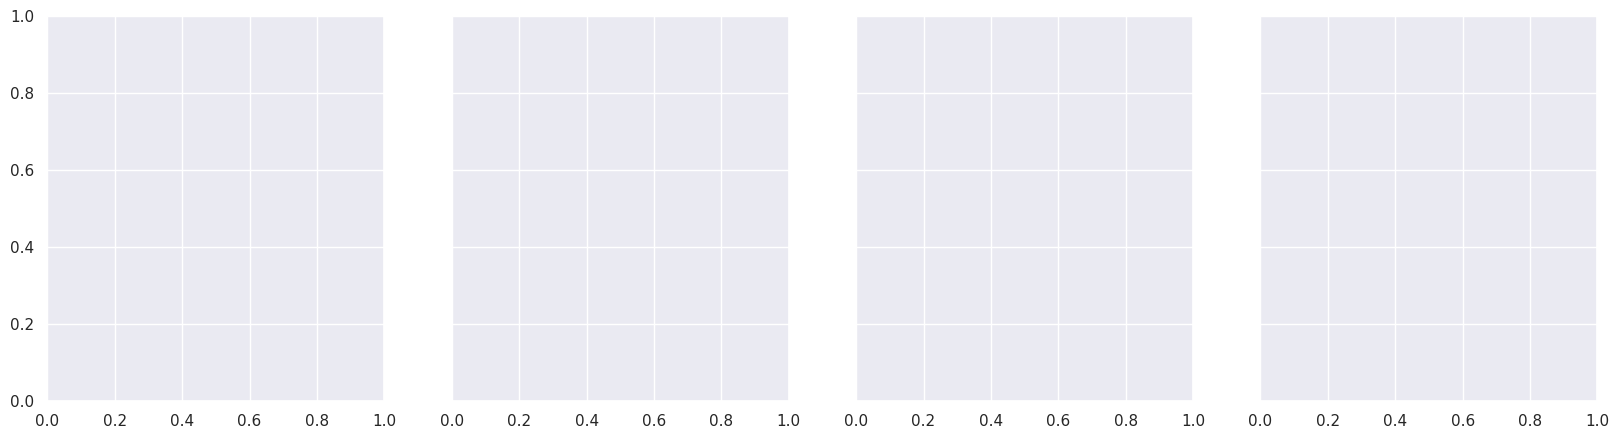

In [111]:
fig, axes = plt.subplots(1,4, figsize=(20, 5), sharey=True)

for i, strat in enumerate(strategies):
    scaleplot(strat, axes.flat[i])

/tmp/ipykernel_170751/425424479.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(df["Threads"].unique())
/tmp/ipykernel_170751/425424479.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(df["Threads"].unique())
/tmp/ipykernel_170751/425424479.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(df["Threads"].unique())
/tmp/ipykernel_170751/425424479.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(df["Threads"].unique())
/tmp/ipykernel_170751/425424479.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or us

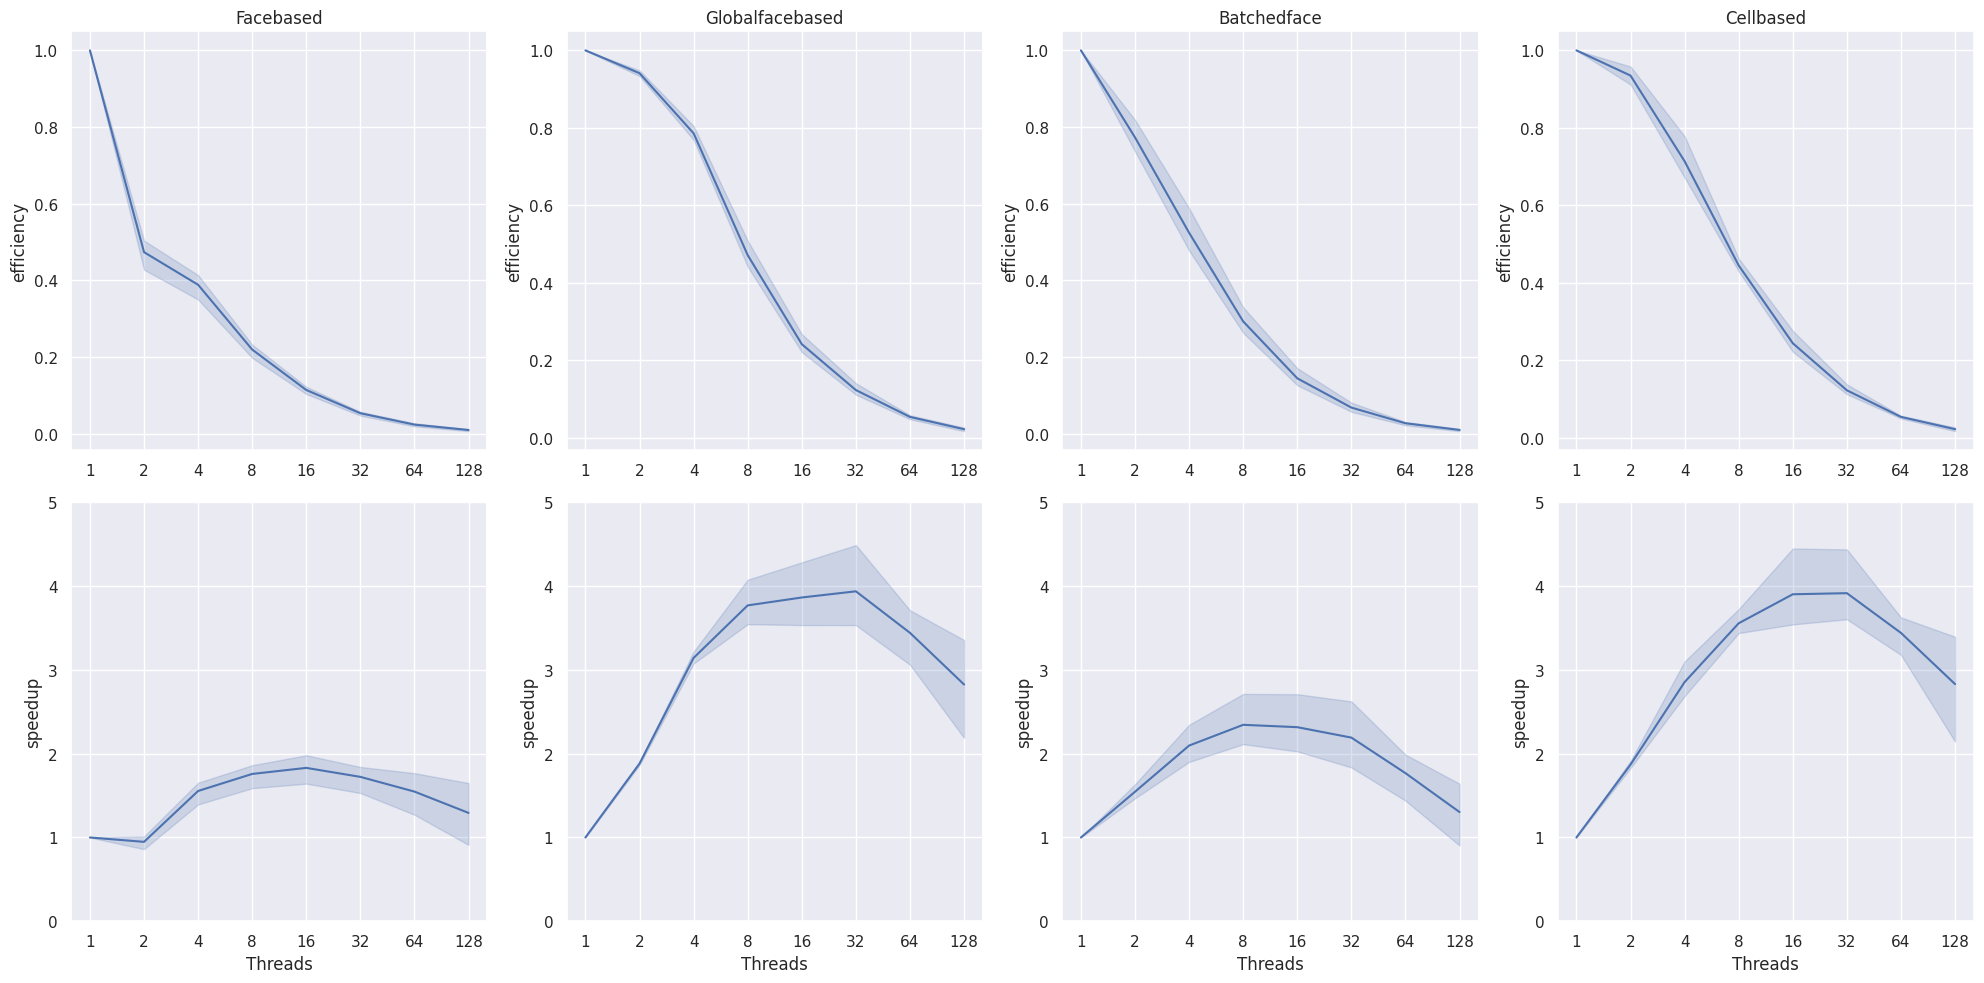

In [155]:
fig, axes = plt.subplots(2,4, figsize=(20, 10), sharey=False, sharex=False)

for i, strat in enumerate(strategies):
    plot = sb.lineplot(data=df[df["strategy"] == strat], x="logth", y="efficiency", ax=axes.flat[i])
    plot.set_title(strat.capitalize())
    plot.set_xticklabels(df["Threads"].unique())
    plot.set(
        xlabel=""
    )
    plot.set_xticks(df["logth"].unique())
    plot = sb.lineplot(data=df[df["strategy"] == strat], x="logth", y="speedup", ax=axes.flat[i+4])
    plot.set_ylim([0, 5])
    plot.set(
        xlabel="Threads"
    )
    plot.set_xticklabels(df["Threads"].unique())
    plot.set_xticks(df["logth"].unique())
plt.tight_layout()
plt.savefig("figures/cpu_scaling.svg")

/tmp/ipykernel_170751/196776744.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(df["Threads"].unique())
/tmp/ipykernel_170751/196776744.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(df["Threads"].unique())
/tmp/ipykernel_170751/196776744.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(df["Threads"].unique())
/tmp/ipykernel_170751/196776744.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(df["Threads"].unique())


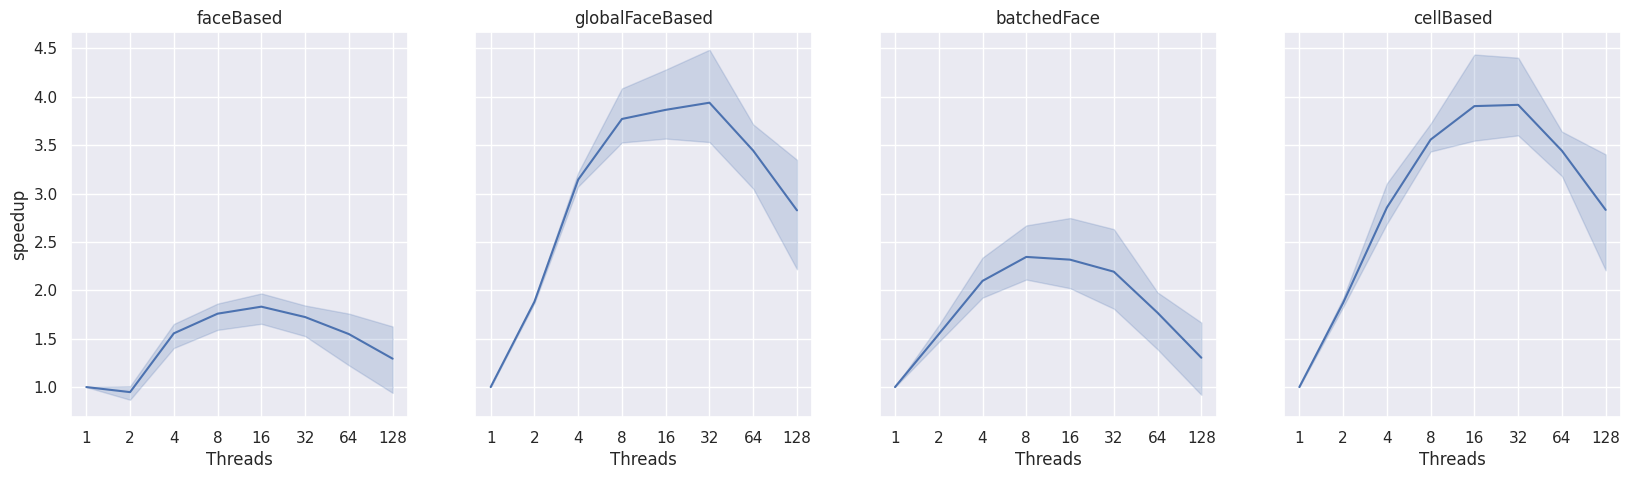

In [ ]:
fig, axes = plt.subplots(1,4, figsize=(20, 5), sharey=True)



In [109]:
df["serial_time"] = df["serial_time_x"]

In [124]:
df["logth"] = [int(math.log2(x)) for x in df["Threads"]]